In [11]:
from pathlib import Path
import os

OUTPUT_DIR = Path("plots/co2_results_008")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(OUTPUT_DIR / ".cache" / "matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(OUTPUT_DIR / ".cache"))

'plots/co2_results_008/.cache'

In [12]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Circle, Wedge
from pyproj import Transformer

from plot_co2_capture_transport_storage import (
    CO2_SECTOR_COLORS,
    CO2_CAPTURE_LEGEND_VALUES,
    get_co2_captured_by_sector,
    get_co2_pipeline_capacity,
    get_co2_pipeline_flows,
    get_co2_stored_by_basin,
    load_china_gdf,
    load_inputs,
    plot_co2_pipeline_flows,
    plot_co2_pipeline_capacity,
    plot_delaunay_lcp_capacity_network,
    plot_co2_storage_circles,
    plot_province_pies,
    write_summary,
)

In [13]:
RESULTS_DIR = Path("results_008/results")
MAP_PATH = Path("../distance_co2pipeline/gadm36_CHN_1.json")
ROUTE_PATH = Path("../improved_co2_pipelines/chinny_co2_pipeline_distance/delaunay_lcp_route_paths_output147.csv")
FLOW_THRESHOLD = 0.0

flows_df, capacity_df = load_inputs(RESULTS_DIR)
gdf = load_china_gdf(gpd, MAP_PATH)

print(f"Loaded results from {RESULTS_DIR}")
print(f"Loaded map from {MAP_PATH}")
print(f"Loaded LCP route paths from {ROUTE_PATH}")

Loaded results from results_008/results
Loaded map from ../distance_co2pipeline/gadm36_CHN_1.json
Loaded LCP route paths from ../improved_co2_pipelines/chinny_co2_pipeline_distance/delaunay_lcp_route_paths_output147.csv


## Build CO2 Summary Tables

In [14]:
co2_captured_by_sector = get_co2_captured_by_sector(flows_df)
co2_stored_by_basin = get_co2_stored_by_basin(flows_df)
co2_pipeline_flows = get_co2_pipeline_flows(flows_df, FLOW_THRESHOLD)
co2_pipeline_capacity = get_co2_pipeline_capacity(capacity_df)

print(f"Capture provinces: {len(co2_captured_by_sector)}")
print(f"Storage sites: {co2_stored_by_basin['Storage Site'].nunique() if not co2_stored_by_basin.empty else 0}")
print(f"Pipeline flows above threshold: {len(co2_pipeline_flows)}")
print(f"Built pipeline capacity routes: {len(co2_pipeline_capacity)}")

display(co2_captured_by_sector.head())
display(co2_stored_by_basin.head())

Capture provinces: 29
Storage sites: 24
Pipeline flows above threshold: 80
Built pipeline capacity routes: 80


,Cement,Steel
Province,,
Anhui,0.256632,0.080856
Beijing,0.494971,0.090154
Chongqing,0.591554,0.058822
Fujian,0.574172,0.064936
Gansu,0.165479,0.046778


,Storage Site,CO2 Stored
6,Hehuai,1.755061
4,Erlian,1.706680
13,Qaidam,1.677132
14,Qinshui,1.530074
9,Nanxiang,1.407040


## CO2 Captured by Sector

The pie-size legend uses fixed values: 1.00, 0.50, and 0.25.

Saved plots/co2_results_008/co2_captured_by_sector.png


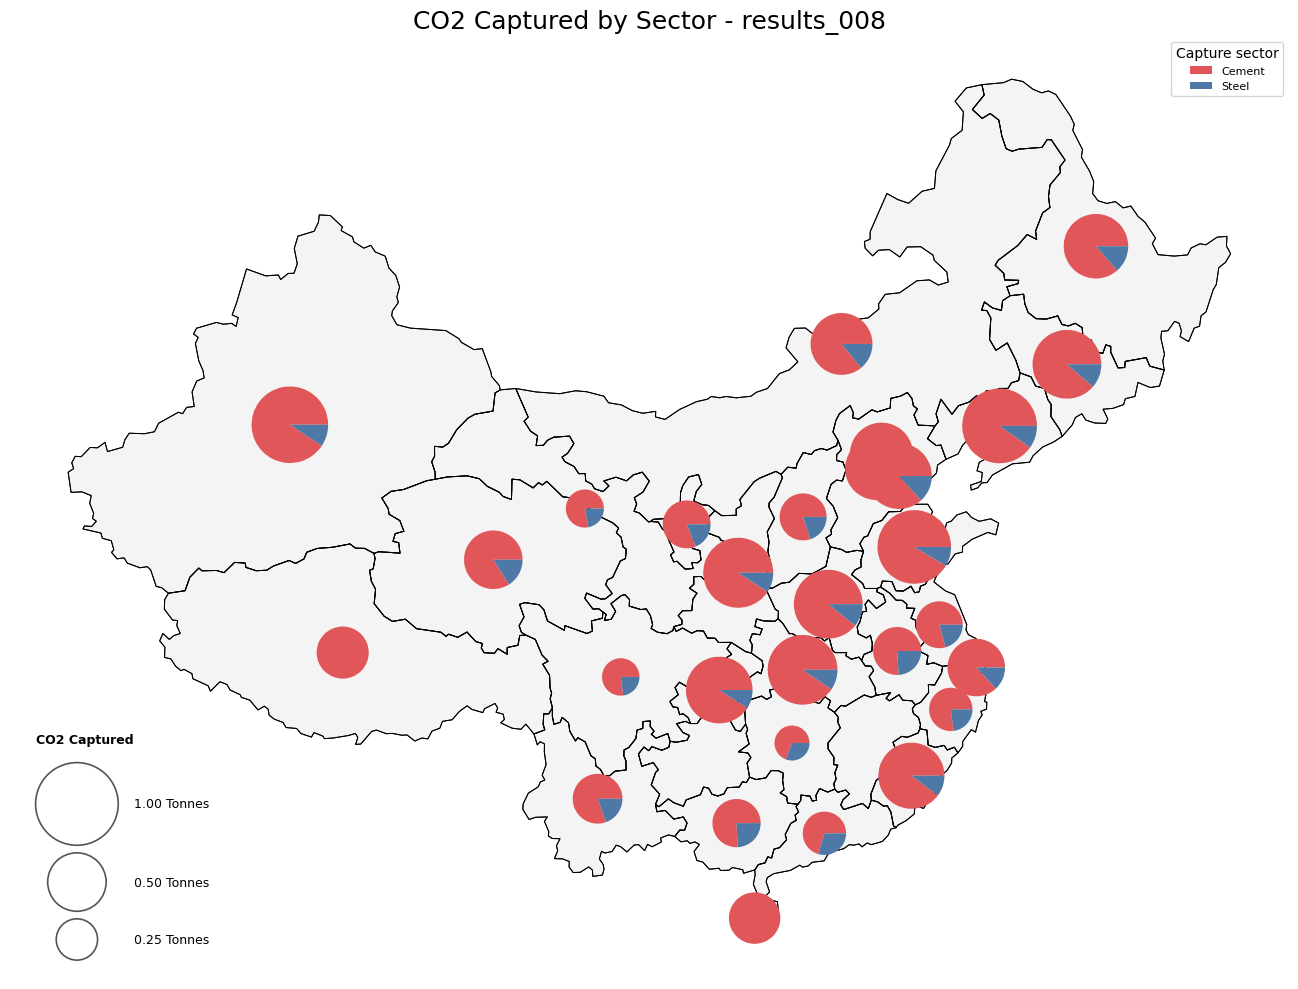

In [15]:
capture_legend = CO2_CAPTURE_LEGEND_VALUES

plot_province_pies(
    gdf,
    co2_captured_by_sector,
    plt,
    Circle,
    Wedge,
    OUTPUT_DIR / "co2_captured_by_sector.png",
    colors=CO2_SECTOR_COLORS,
    title=f"CO2 Captured by Sector - {RESULTS_DIR.parent.name}",
    size_legend=capture_legend,
    show=True,
)

## CO2 Pipeline Flows

Saved plots/co2_results_008/co2_pipeline_flows.png


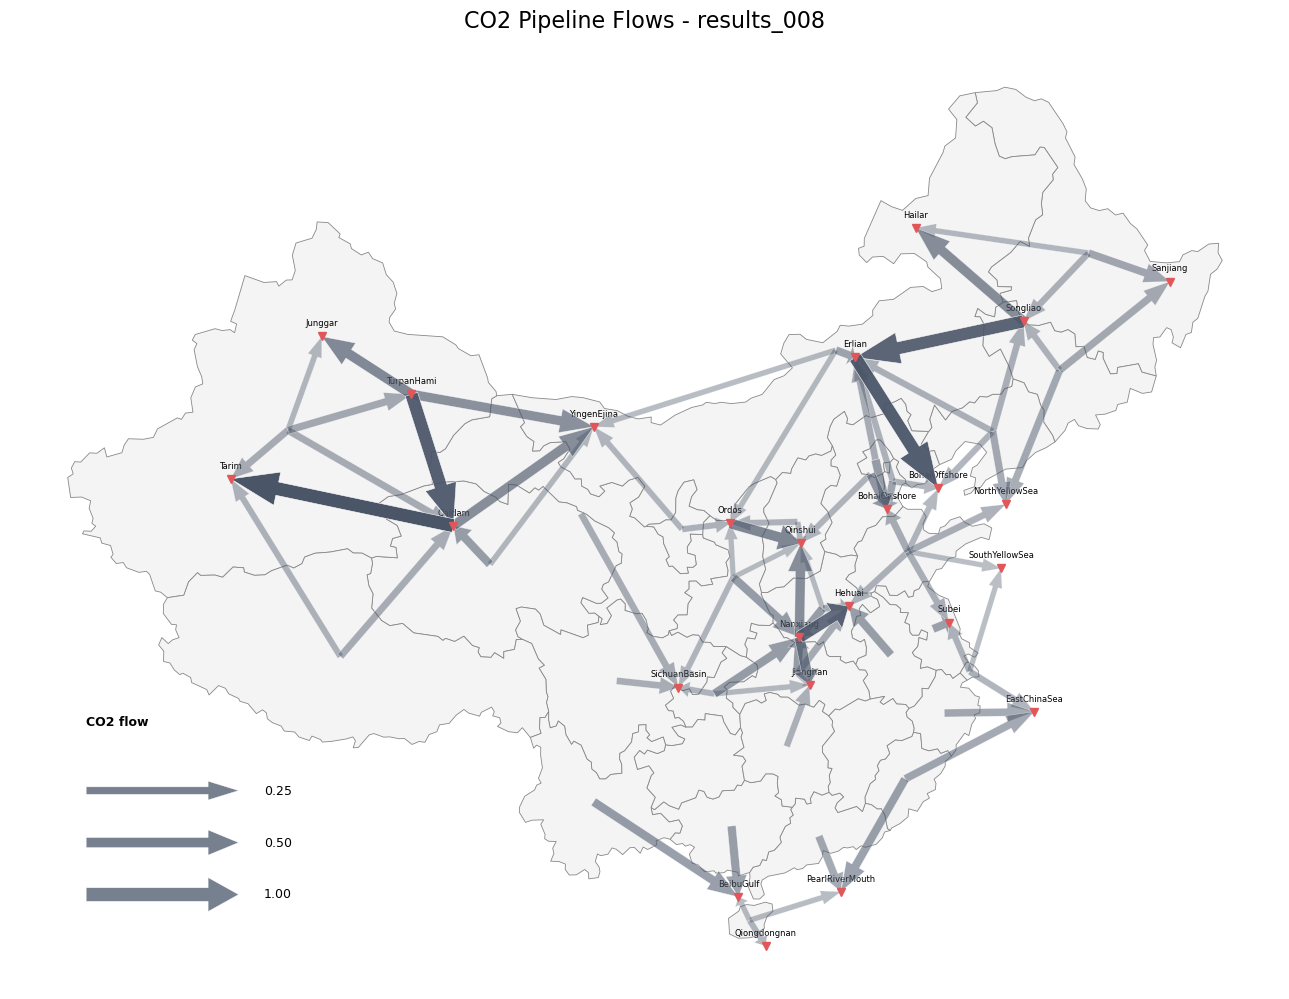

In [16]:
plot_co2_pipeline_flows(
    co2_pipeline_flows,
    co2_pipeline_capacity,
    gdf,
    plt,
    Line2D,
    Transformer,
    OUTPUT_DIR / "co2_pipeline_flows.png",
    title=f"CO2 Pipeline Flows - {RESULTS_DIR.parent.name}",
    show_capacity_routes=False,
    show=True,
)

## Static Delaunay LCP Capacity Network

This PNG uses the non-straight LCP route polylines extracted from methodology output 147. Thin red lines show the full Delaunay LCP candidate network; thicker red lines show routes with built capacity from `capacity.csv`.

Used pipeline route table: ../improved_co2_pipelines/chinny_co2_pipeline_distance/delaunay_lcp_route_paths_output147.csv
Saved plots/co2_results_008/co2_pipeline_capacity_delaunay_lcp.png


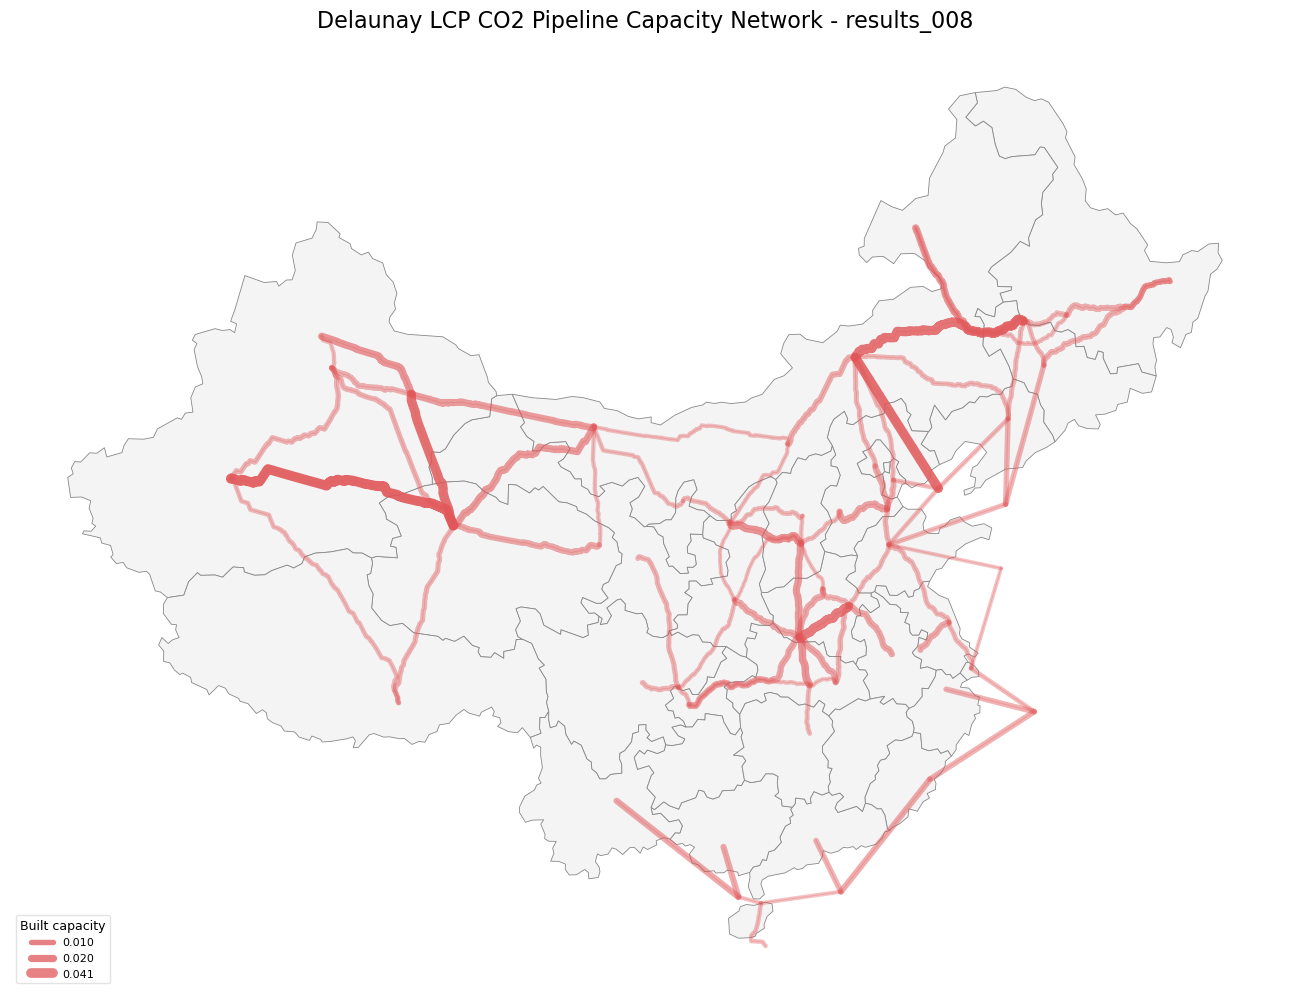

In [17]:
plot_co2_pipeline_capacity(
    co2_pipeline_capacity,
    gdf,
    plt,
    Line2D,
    Transformer,
    OUTPUT_DIR / "co2_pipeline_capacity_delaunay_lcp.png",
    route_path=ROUTE_PATH,
    title=f"Delaunay LCP CO2 Pipeline Capacity Network - {RESULTS_DIR.parent.name}",
    show_delaunay_network=True,
    show=True,
)

## Interactive Delaunay LCP Capacity Network

This recreates the methodology-style non-straight LCP network from output 147. Route width is scaled by built capacity from `results_008/results/capacity.csv`, and an HTML copy is saved to `OUTPUT_DIR`.

In [18]:
fig_lcp_capacity = plot_delaunay_lcp_capacity_network(
    co2_pipeline_capacity,
    gdf,
    route_path=ROUTE_PATH,
    title=f"Delaunay LCP Network with Built CO2 Pipeline Capacity - {RESULTS_DIR.parent.name}",
    output_html=OUTPUT_DIR / "delaunay_lcp_capacity_network.html",
    show=True,
)

Saved plots/co2_results_008/delaunay_lcp_capacity_network.html


## CO2 Stored by Basin

The storage-size legend uses fixed values: 0.50, 1.00, and 1.75.

Saved plots/co2_results_008/co2_stored_by_basin.png


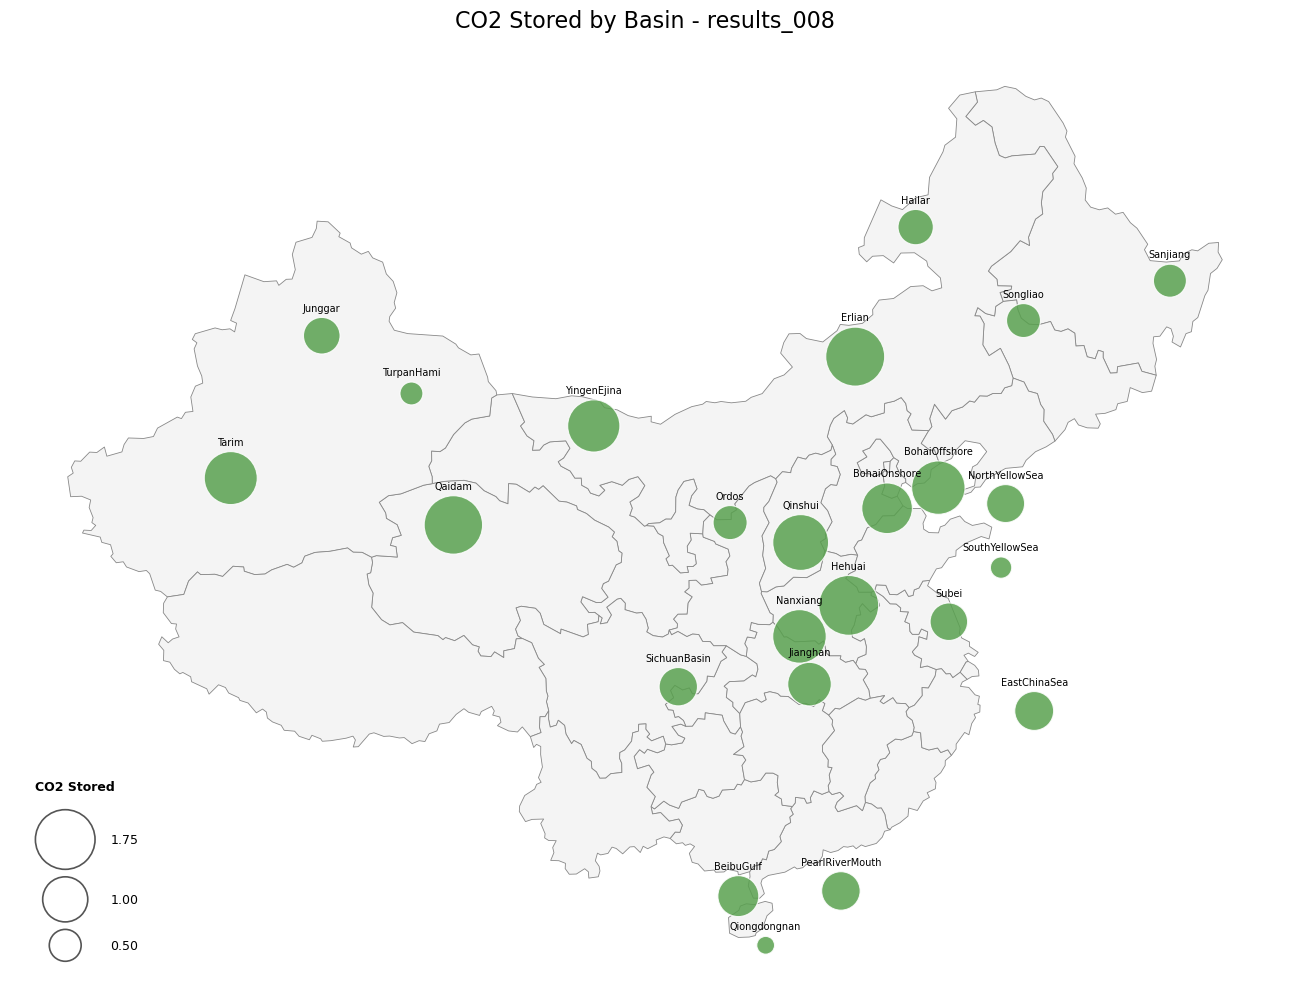

In [19]:
plot_co2_storage_circles(
    co2_stored_by_basin,
    gdf,
    plt,
    Circle,
    Transformer,
    OUTPUT_DIR / "co2_stored_by_basin.png",
    title=f"CO2 Stored by Basin - {RESULTS_DIR.parent.name}",
    show=True,
)

## Save Summary CSVs

In [20]:
write_summary(OUTPUT_DIR, co2_captured_by_sector, co2_stored_by_basin, co2_pipeline_flows)